In [ ]:
#import libraries

#for data handling purposes
import pandas as pd
import numpy as np

#for data visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#load dataset

df = pd.read_csv("Dataset.csv")
df.head()   #display first 5 rows

,County,Year,Population,Index Count,Index Rate,Violent Count,Violent Rate,Property Count,Property Rate,Firearm Count,Firearm Rate
0,Albany,1990,292594.0,14418,4927.6,1524,520.9,12894,4406.8,122.0,41.7
1,Albany,1991,294030.0,15464,5259.3,1674,569.3,13790,4690.0,120.0,40.8
2,Albany,1992,295018.0,16249,5507.8,1588,538.3,14661,4969.5,116.0,39.3
3,Albany,1993,294302.0,15139,5144.0,1669,567.1,13470,4576.9,104.0,35.3
4,Albany,1994,293843.0,16724,5691.5,1771,602.7,14953,5088.8,162.0,55.1


In [ ]:
#explore the dataset

df.info()  #dataset column names and non null counts of each row and datatypes

#so as output we have null values in Firearm count and Firearm Rate columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2170 entries, 0 to 2169
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   County          2170 non-null   object 
 1   Year            2170 non-null   int64  
 2   Population      2170 non-null   float64
 3   Index Count     2170 non-null   int64  
 4   Index Rate      2170 non-null   float64
 5   Violent Count   2170 non-null   int64  
 6   Violent Rate    2170 non-null   float64
 7   Property Count  2170 non-null   int64  
 8   Property Rate   2170 non-null   float64
 9   Firearm Count   2105 non-null   float64
 10  Firearm Rate    2105 non-null   float64
dtypes: float64(6), int64(4), object(1)
memory usage: 186.6+ KB


In [ ]:
df.describe()  #statistical view of the dataset

,Year,Population,Index Count,Index Rate,Violent Count,Violent Rate,Property Count,Property Rate,Firearm Count,Firearm Rate
count,2170.000000,2.170000e+03,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2105.000000,2105.000000
mean,2007.000000,3.079418e+05,9138.796313,2308.153641,1670.914747,271.685161,7467.881567,2036.468295,280.185748,33.601995
std,10.101833,5.214086e+05,20826.471736,1201.689549,5226.084112,279.489289,16005.563719,1011.944658,1375.338705,77.546184
min,1990.000000,4.342000e+03,21.000000,277.800000,1.000000,19.100000,18.000000,221.100000,0.000000,0.000000
25%,1998.000000,5.143225e+04,943.000000,1539.900000,88.000000,139.700000,831.250000,1357.225000,4.000000,7.500000
50%,2007.000000,9.045400e+04,1902.500000,2135.100000,173.000000,201.550000,1734.500000,1888.450000,10.000000,14.600000
75%,2016.000000,2.353492e+05,6113.250000,2784.450000,649.000000,304.750000,5449.500000,2520.700000,79.000000,32.000000
max,2024.000000,2.646816e+06,217786.000000,14651.100000,63087.000000,2989.200000,173352.000000,11661.900000,21878.000000,948.000000


In [ ]:
df.isnull().sum()   #each column sum of the null data as previously mentioned columns include null values

County             0
Year               0
Population         0
Index Count        0
Index Rate         0
Violent Count      0
Violent Rate       0
Property Count     0
Property Rate      0
Firearm Count     65
Firearm Rate      65
dtype: int64

In [ ]:
#identify duplicates

duplicate_rows = df[df.duplicated()]

print(duplicate_rows)

#number of duplicate rows
duplicate_count = df.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

#no duplicates

Empty DataFrame
Columns: [County, Year, Population, Index Count, Index Rate, Violent Count, Violent Rate, Property Count, Property Rate, Firearm Count, Firearm Rate]
Index: []
Total duplicate rows: 0


In [ ]:
#before handling the missing data

#1. check the missing pattern of data

df[df['Firearm Rate'].isnull()].groupby('Year').size()

Year
2002    5
2003    5
2004    5
2005    5
2006    5
2007    5
2008    5
2009    5
2010    5
2011    5
2012    5
2013    5
2014    5
dtype: int64

In [ ]:
df[df['Firearm Count'].isnull()].groupby('Year').size()

Year
2002    5
2003    5
2004    5
2005    5
2006    5
2007    5
2008    5
2009    5
2010    5
2011    5
2012    5
2013    5
2014    5
dtype: int64

In [ ]:
#so according to above output missing values in Firearm Rate and Firearm Count columns are not random, not only in early years.
#It's consistent across multiple years. (Like missing for specific counties)

In [ ]:
df = df.sort_values(['County', 'Year']) #sort the data by County and Year. we used this to not to break trend and prevention of using wrong values

print(df)

      County  Year  Population  Index Count  Index Rate  Violent Count  \
0     Albany  1990    292594.0        14418      4927.6           1524   
1     Albany  1991    294030.0        15464      5259.3           1674   
2     Albany  1992    295018.0        16249      5507.8           1588   
3     Albany  1993    294302.0        15139      5144.0           1669   
4     Albany  1994    293843.0        16724      5691.5           1771   
...      ...   ...         ...          ...         ...            ...   
2165   Yates  2020     24704.0          221       894.6             16   
2166   Yates  2021     25366.0          183       721.4             34   
2167   Yates  2022     24702.0          197       797.5             27   
2168   Yates  2023     24444.0          164       670.9             28   
2169   Yates  2024     24975.0          173       692.7             16   

      Violent Rate  Property Count  Property Rate  Firearm Count  Firearm Rate  
0            520.9           1

In [ ]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
grouped = df.groupby('County')  #grouped data by County because each County has different crime patterns
grouped.size()

County
Albany         35
Allegany       35
Bronx          35
Broome         35
Cattaraugus    35
               ..
Washington     35
Wayne          35
Westchester    35
Wyoming        35
Yates          35
Length: 62, dtype: int64

In [ ]:
df[['Firearm Count', 'Firearm Rate']] = df.groupby('County')[
    ['Firearm Count', 'Firearm Rate']
].transform(lambda x: x.interpolate(method='linear'))

#For each county, fill missing firearm crime values using nearby yearly values with linear estimation.
#Start value = 100
#End value = 140
#Missing value in middle

#So it calculates:

#100+ (140-100/2)
#100+20=120

#used this method linear interpolation because dataset is time-series crime data.
#And Linear interpolation estimates missing values using nearby values while preserving the natural trend of the data.

In [ ]:
df.head()

,County,Year,Population,Index Count,Index Rate,Violent Count,Violent Rate,Property Count,Property Rate,Firearm Count,Firearm Rate
0,Albany,1990,292594.0,14418,4927.6,1524,520.9,12894,4406.8,122.0,41.7
1,Albany,1991,294030.0,15464,5259.3,1674,569.3,13790,4690.0,120.0,40.8
2,Albany,1992,295018.0,16249,5507.8,1588,538.3,14661,4969.5,116.0,39.3
3,Albany,1993,294302.0,15139,5144.0,1669,567.1,13470,4576.9,104.0,35.3
4,Albany,1994,293843.0,16724,5691.5,1771,602.7,14953,5088.8,162.0,55.1


In [ ]:
df[['Firearm Count', 'Firearm Rate']].isnull().sum()  #check still having any null values

Firearm Count    0
Firearm Rate     0
dtype: int64

In [ ]:
df['Firearm Count'] = df['Firearm Count'].round() #round off values to nearest whole number

In [ ]:
df['Firearm Rate'] = df['Firearm Rate'].round(2) #round off values to 2 decimal points

In [ ]:
df['Population'] = df['Population'].round(2) #round off values to nearest whole number

In [ ]:
df.columns = df.columns.str.replace(' ', '_') #remove spaces of column names by replacing spaces with underscore

In [ ]:
df['Firearm_Count'] = df['Firearm_Count'].astype(int) #Firearm Count is integer type so change the type to integer type

In [ ]:
df['Population'] = df['Population'].astype(int) #Population is integer type so change the type to integer type

In [ ]:
df['Property_Count'] = df['Property_Count'].astype(int) #Property Count is integer type so change the type to integer type

In [ ]:
df['Firearm_Count'].head()
df['Firearm_Count'].dtype  #check the data type of Firearm Count again to verify that data type is changed

dtype('int64')

In [ ]:
df.head() #check again

,County,Year,Population,Index_Count,Index_Rate,Violent_Count,Violent_Rate,Property_Count,Property_Rate,Firearm_Count,Firearm_Rate
0,Albany,1990,292594,14418,4927.6,1524,520.9,12894,4406.8,122,41.7
1,Albany,1991,294030,15464,5259.3,1674,569.3,13790,4690.0,120,40.8
2,Albany,1992,295018,16249,5507.8,1588,538.3,14661,4969.5,116,39.3
3,Albany,1993,294302,15139,5144.0,1669,567.1,13470,4576.9,104,35.3
4,Albany,1994,293843,16724,5691.5,1771,602.7,14953,5088.8,162,55.1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2170 entries, 0 to 2169
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   County          2170 non-null   object 
 1   Year            2170 non-null   int64  
 2   Population      2170 non-null   int64  
 3   Index_Count     2170 non-null   int64  
 4   Index_Rate      2170 non-null   float64
 5   Violent_Count   2170 non-null   int64  
 6   Violent_Rate    2170 non-null   float64
 7   Property_Count  2170 non-null   int64  
 8   Property_Rate   2170 non-null   float64
 9   Firearm_Count   2170 non-null   int64  
 10  Firearm_Rate    2170 non-null   float64
dtypes: float64(4), int64(6), object(1)
memory usage: 186.6+ KB


In [ ]:
#now dataset is ready to use
df.to_csv("cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [ ]:
#Now moving to EDA part: identify trends, patterns, and relationships

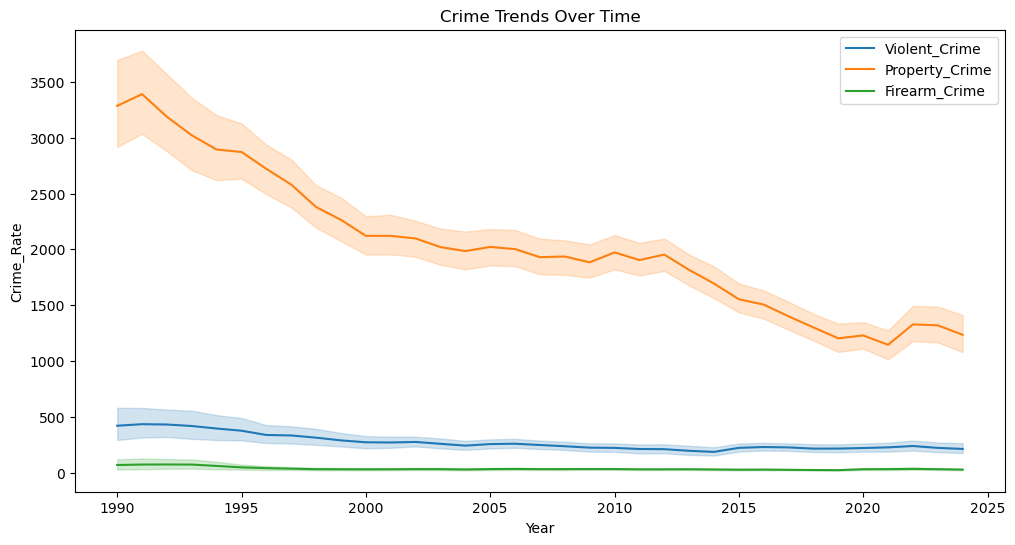

In [ ]:
#Analyzing the Crime Trend Over Time

plt.figure(figsize=(12,6))

sns.lineplot(data=df, x='Year', y='Violent_Rate', label='Violent_Crime')
sns.lineplot(data=df, x='Year', y='Property_Rate', label='Property_Crime')
sns.lineplot(data=df, x='Year', y='Firearm_Rate', label='Firearm_Crime')

plt.title('Crime Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Crime_Rate')
plt.legend()
plt.show()

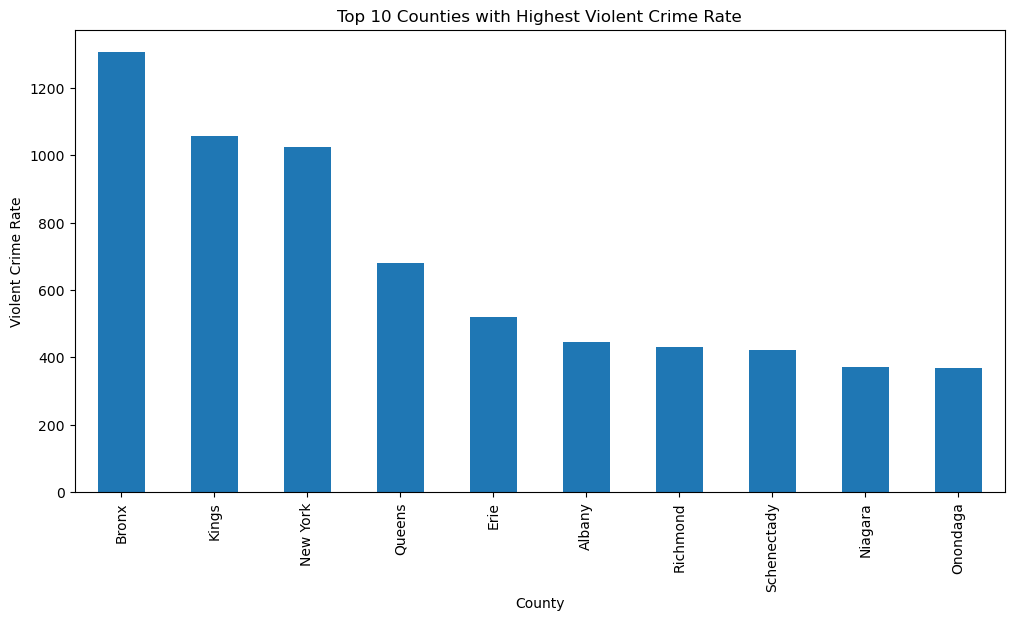

In [ ]:
#Compare Counties by Crime Rate

county_avg = df.groupby('County')[['Violent_Rate', 'Property_Rate', 'Firearm_Rate']].mean()

county_avg.sort_values(by='Violent_Rate', ascending=False).head(10)

county_avg['Violent_Rate'].sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top 10 Counties with Highest Violent Crime Rate')
plt.ylabel('Violent Crime Rate')
plt.show()

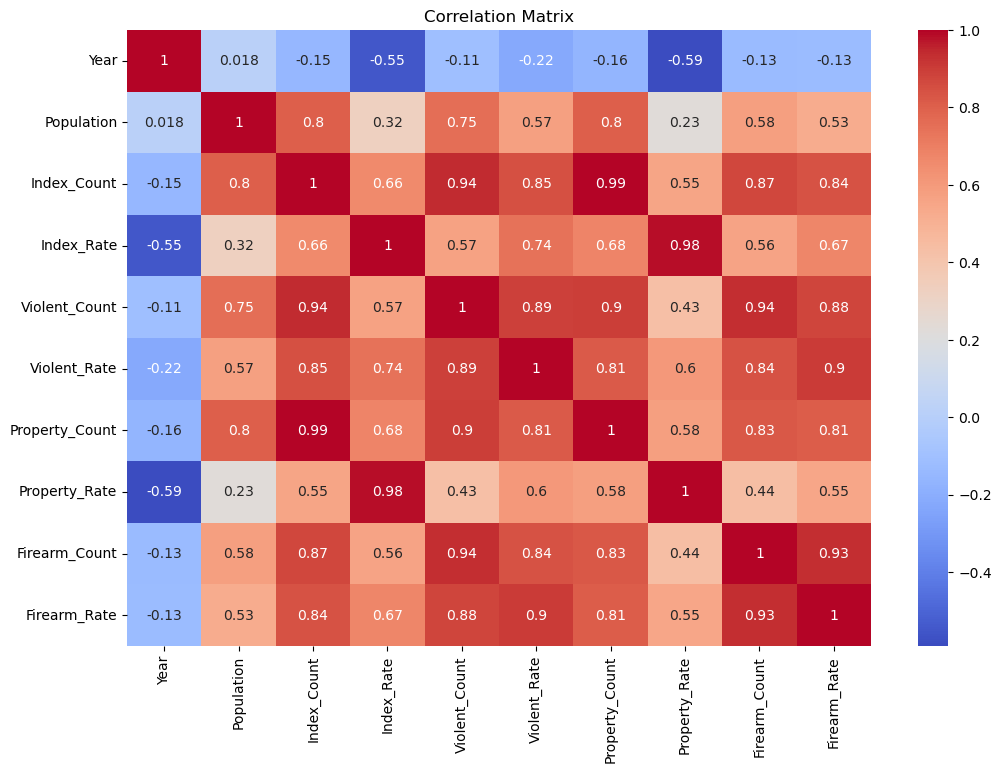

In [ ]:
#Correlation Heatmap: This identifies relationships between variables.

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

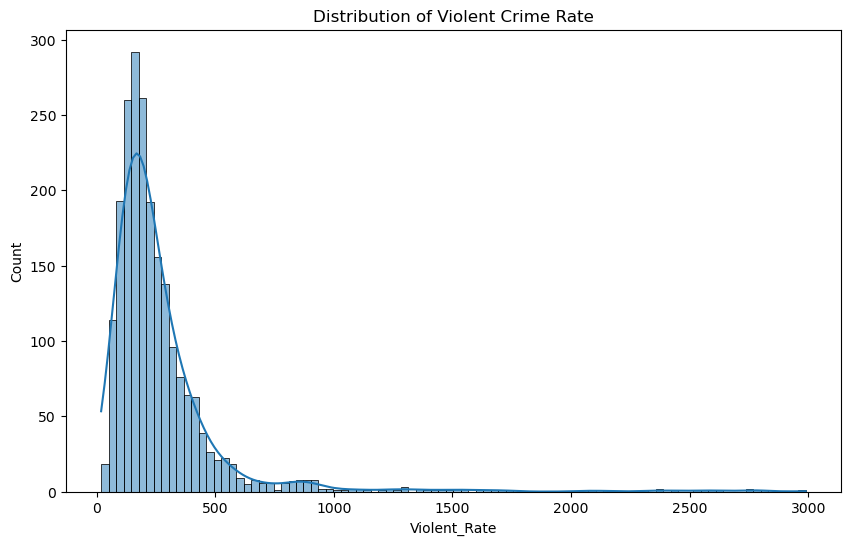

In [ ]:
#Distribution Analysis
plt.figure(figsize=(10,6))

sns.histplot(df['Violent_Rate'], kde=True)

plt.title('Distribution of Violent Crime Rate')
plt.show()

In [ ]:
#Advanced Feature Engineering
#Create Forecast Target
#Predict next year's violent crime rate.
df['Future_Violent_Rate'] = (
    df.groupby('County')['Violent_Rate']
      .shift(-1)
)

In [ ]:
#Lag Features
df['Violent_Lag1'] = (
    df.groupby('County')['Violent_Rate']
      .shift(1)
)

df['Violent_Lag2'] = (
    df.groupby('County')['Violent_Rate']
      .shift(2)
)

df['Property_Lag1'] = (
    df.groupby('County')['Property_Rate']
      .shift(1)
)

df['Property_Lag2'] = (
    df.groupby('County')['Property_Rate']
      .shift(2)
)

df['Firearm_Lag1'] = (
    df.groupby('County')['Firearm_Rate']
      .shift(1)
)

df['Firearm_Lag2'] = (
    df.groupby('County')['Firearm_Rate']
      .shift(2)
)

In [ ]:
#Rolling Average Features
df['Violent_MA3'] = (
    df.groupby('County')['Violent_Rate']
      .transform(lambda x: x.rolling(3).mean())
)

df['Property_MA3'] = (
    df.groupby('County')['Property_Rate']
      .transform(lambda x: x.rolling(3).mean())
)

df['Firearm_MA3'] = (
    df.groupby('County')['Firearm_Rate']
      .transform(lambda x: x.rolling(3).mean())
)

In [ ]:
#Growth Features
df['Violent_Growth'] = (
    df.groupby('County')['Violent_Rate']
      .pct_change()
)

df['Property_Growth'] = (
    df.groupby('County')['Property_Rate']
      .pct_change()
)

df['Firearm_Growth'] = (
    df.groupby('County')['Firearm_Rate']
      .pct_change()
)

In [ ]:
#Historical County Averages
df['County_Avg_Violent'] = (
    df.groupby('County')['Violent_Rate']
      .transform('mean')
)

df['County_Avg_Property'] = (
    df.groupby('County')['Property_Rate']
      .transform('mean')
)

df['County_Avg_Firearm'] = (
    df.groupby('County')['Firearm_Rate']
      .transform('mean')
)

In [ ]:
#Crime Risk Level
df['Crime_Risk_Level'] = pd.qcut(
    df['Violent_Rate'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [ ]:
df = df.dropna()

print(df.shape)

(1958, 28)


In [ ]:
#Define Features and Target
#Target Variable
y = df['Future_Violent_Rate']
#Feature Variables
X = df.drop(
    columns=['Future_Violent_Rate']
)

In [ ]:
#Encode Categorical Variables
X = pd.get_dummies(
    X,
    drop_first=True
)

# FIX 2: Save feature names here, before X is converted to a numpy array
feature_names = X.columns.tolist()

In [ ]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1566, 88)
(392, 88)


In [ ]:
import numpy as np
import pandas as pd

df_check = pd.DataFrame(X_train)

# check infinity
print(np.isinf(df_check).sum())

# check NaN
print(np.isnan(df_check).sum())

Year                       0
Population                 0
Index_Count                0
Index_Rate                 0
Violent_Count              0
                          ..
County_Westchester         0
County_Wyoming             0
County_Yates               0
Crime_Risk_Level_Medium    0
Crime_Risk_Level_High      0
Length: 88, dtype: int64
Year                       0
Population                 0
Index_Count                0
Index_Rate                 0
Violent_Count              0
                          ..
County_Westchester         0
County_Wyoming             0
County_Yates               0
Crime_Risk_Level_Medium    0
Crime_Risk_Level_High      0
Length: 88, dtype: int64


In [ ]:
import numpy as np

X_train = np.where(np.isinf(X_train), np.nan, X_train)
X_test = np.where(np.isinf(X_test), np.nan, X_test)

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [ ]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr_model.predict(
    X_test_scaled
)

print(y_pred_lr)

[ 130.58033633  201.29869909  819.32563821  199.32444908  124.57110841
 1325.90416352  332.07704538   58.73597563  348.31081244  251.1956031
  250.09941071   81.02783441  259.4277192   176.82659189  579.21494572
  349.85636358  297.06197226  165.23430626  410.92603307  174.71553478
  551.58439062  234.31238602  161.07368383  235.74612155  100.16212055
   79.34442422  246.93413793 1518.51784347  267.52170927  466.81611173
  365.52859648  748.97756223  123.88976045  162.31131824  113.06513138
  247.83911864  230.04310952  188.16989538  382.35932837  166.44517505
   73.53588561  122.2409841   223.64829161 1430.91920611  151.98561805
  168.31287261  106.28937522  129.86923235 1194.75697062  216.05814002
  137.29808654  240.94396801  195.17498672   88.71429947  277.59285919
  241.04019283  198.26438821  192.72084201  254.25828974  295.80857468
  383.54586601  339.17806038  372.12087555  109.06633718  196.75824137
  186.43638785  416.88594346  304.4496738   276.78634019  213.92177096
  296.7

In [ ]:
#Evaluate Linear Regression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression Results
MAE: 29.864786105299814
RMSE: 45.870620984882976
R2: 0.9720069956040128


In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

In [ ]:
#Evaluate Random Forest
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Results
MAE: 31.60661090052602
RMSE: 48.760375535431635
R2: 0.968368895513818


In [ ]:
import numpy as np

# FIX: Convert X back to DataFrame using saved feature_names for NaN/Inf checks
X_check = pd.DataFrame(X_train, columns=feature_names)
print("Any NaN:", np.isnan(X_train).sum())
print("Any Inf:", np.isinf(X_train).sum())

Any NaN: 0
Any Inf: 0


In [ ]:
import numpy as np

print((X_train == np.inf).sum())
print((X_train == -np.inf).sum())

0
0


In [ ]:
#Cross Validation
from sklearn.model_selection import cross_val_score

# FIX: Use X_train (imputed numpy array) and y_train for cross validation
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print(cv_scores)
print("Average CV Score:", cv_scores.mean())

[0.94462798 0.95964817 0.96320838 0.92763485 0.95018548]
Average CV Score: 0.9490609710211239


In [ ]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(
    X_train,
    y_train
)

best_model = grid.best_estimator_

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 300}


In [ ]:
#Compare Models
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        mae_lr,
        mae_rf
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf
    ],
    'R2 Score': [
        r2_lr,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,29.864786,45.870621,0.972007
1,Random Forest,31.606611,48.760376,0.968369


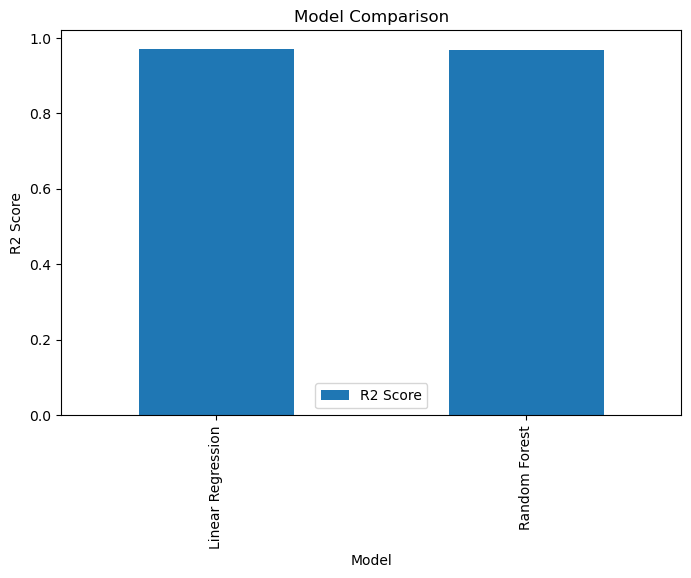

In [ ]:
#Model Comparison Chart
import pandas as pd
import matplotlib.pyplot as plt

# FIX 1: Use r2_lr and r2_rf (already computed above), not undefined lr_score / rf_score
results_chart = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [r2_lr, r2_rf]
})

results_chart.plot(
    x='Model',
    y='R2 Score',
    kind='bar',
    figsize=(8, 5)
)

plt.title('Model Comparison')
plt.ylabel('R2 Score')
plt.show()

In [ ]:
# FIX 2: Use saved feature_names list (X was converted to numpy array earlier)
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
5,Violent_Rate,0.766711
16,Violent_MA3,0.117803
11,Violent_Lag2,0.023052
10,Violent_Lag1,0.020742
15,Firearm_Lag2,0.018275
9,Firearm_Rate,0.009946
18,Firearm_MA3,0.007486
14,Firearm_Lag1,0.005235
22,County_Avg_Violent,0.004528
0,Year,0.002626


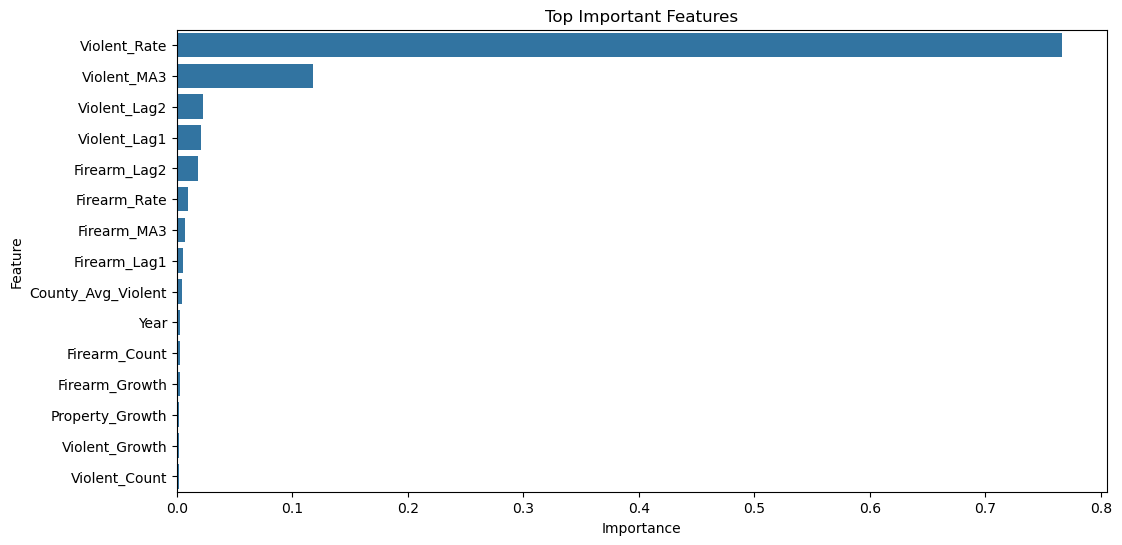

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top Important Features')

plt.show()

In [ ]:
# FIX 3: best_model was trained on X_train (imputed numpy array), so predict on X_test (same format)
forecast_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': best_model.predict(X_test)
})

forecast_df.head()

,Actual,Predicted
0,153.8,131.038517
1,273.2,213.481053
2,846.8,885.796674
3,215.0,198.698168
4,122.1,125.252243


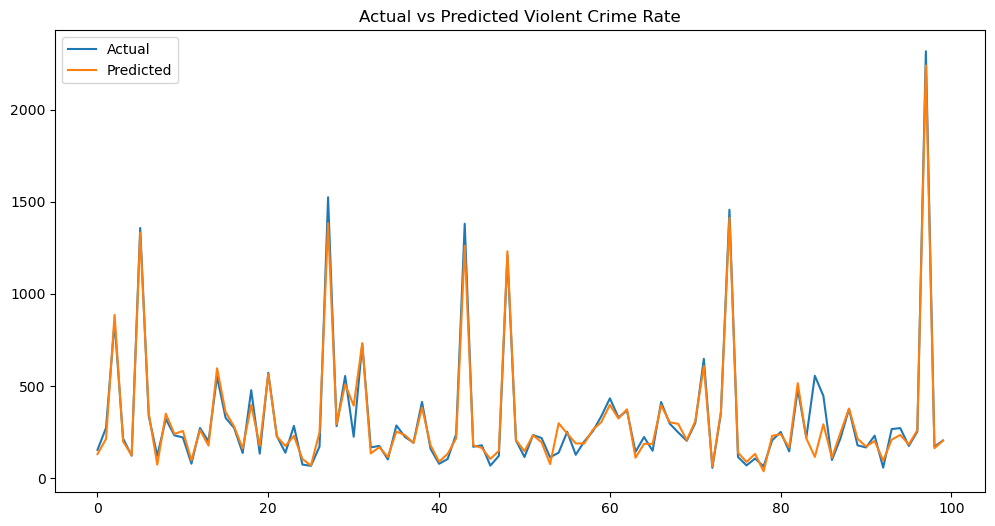

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    forecast_df['Actual'].values[:100],
    label='Actual'
)

plt.plot(
    forecast_df['Predicted'].values[:100],
    label='Predicted'
)

plt.title('Actual vs Predicted Violent Crime Rate')

plt.legend()

plt.show()

In [ ]:
import joblib

joblib.dump(
    best_model,
    'crime_prediction_model.pkl'
)

joblib.dump(
    scaler,
    'scaler.pkl'
)

# FIX 4: Save feature_names so the Streamlit app can build the correct input shape
joblib.dump(
    feature_names,
    'feature_names.pkl'
)

print("Model saved successfully")

Model saved successfully
